Testing orchestration of the two agents (rooms and information) with LangGraph

In [ ]:
from pathlib import Path

import nest_asyncio
from dotenv import load_dotenv

from blue_horizon.agents.information import (
    InfoAgentFactory,
    InfoRagResources,
    get_redis_url,
    load_info_config,
)
from blue_horizon.agents.rooms import (
    RoomsAgentFactory,
    RoomsSqlResources,
    get_pgsql_db_url,
    load_rooms_config,
)

nest_asyncio.apply()
load_dotenv()

gpt_model = "gpt-5-nano"

Setup the information agent

In [7]:
info_rag_config = load_info_config(Path.cwd() / "../blue_horizon/app_config.toml")
info_rag_resources = InfoRagResources(redis_url=get_redis_url(), config=info_rag_config)
await info_rag_resources.startup_check()
info_agent_factory = InfoAgentFactory(resources=info_rag_resources, config=info_rag_config)

Setup the rooms agent

In [ ]:
rooms_sql_config = load_rooms_config(Path.cwd() / "../blue_horizon/app_config.toml")
rooms_sql_resources = RoomsSqlResources(pgsql_db_url=get_pgsql_db_url(), config=rooms_sql_config)
await rooms_sql_resources.startup_check()
rooms_agent_factory = RoomsAgentFactory(config=rooms_sql_config, resources=rooms_sql_resources)

In [10]:
info_agent = info_agent_factory.build()
rooms_agent = rooms_agent_factory.build()

In [11]:
def get_output_text(query_result) -> str:
    last_result = query_result["messages"][-1]
    for c in last_result.content:
        if "text" in c:
            return c["text"]
    return ""

In [6]:
prompt = "What dining options are there?"
result = await info_agent.ainvoke({"messages": [{"role": "user", "content": prompt}]})
print(get_output_text(result))

15:41:16 redisvl.index.index INFO   Index already exists, not overwriting.
15:41:16 redisvl.index.index INFO   Index already exists, not overwriting.
15:41:17 redisvl.index.index INFO   Index already exists, not overwriting.
I looked up the hotel’s dining-related options and found the following:

Room service is available 24/7, with a full menu during restaurant hours and a limited menu overnight. Breakfast is included with most room rates (please check your booking details), and the hotel also lists an on-site restaurant.

**Evening Dining**
  **Category:** Room Service
  **Price (USD):** 65
  **Duration (minutes):** 45
  **Availability:** 8:00-20:00
  **Booking required:** False
  **Minimum notice (hours):** 0
  **Description:** Indulge in the convenience of our Evening Dining, where 45 minutes of professional service presentation brings satisfies your gourmet cravings, providing perfect satisfaction.

I couldn’t find additional specifics here (e.g., restaurant name, menus, or restau

In [7]:
prompt = 'Show me rooms with a view of the ocean and a 55" TV'
result = await rooms_agent.ainvoke({"messages": [{"role": "user", "content": prompt}]})
print(get_output_text(result))

I found these rooms that have an ocean view and a 55" Smart TV:

- Room 502 — Floor 5 — Deluxe — 460 sq ft — Max occupancy 3 — Bed: Double Queen  
  Views: [Pool View, Ocean View]  
  Amenities: [Air Conditioning, 55" Smart TV, Nespresso Machine, Mini Fridge, Hair Dryer, In-Room Safe, Work Desk, High-Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers, Evening Turndown Service]  
  Additional amenities: [Soaking Tub]  
  Accessibility: no

- Room 503 — Floor 5 — Deluxe — 538 sq ft — Max occupancy 3 — Bed: Double Queen  
  Views: [Pool View, Ocean View]  
  Amenities: [Air Conditioning, 55" Smart TV, Nespresso Machine, Mini Fridge, Hair Dryer, In-Room Safe, Work Desk, High-Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers, Evening Turndown Service]  
  Additional amenities: [Soaking Tub, Lounge Access, Balcony]  
  Accessibility: no

- Room 504 — Floor 5 — Deluxe — 565 sq ft — Max occupancy 3 — Bed: Double Queen  
  Views: [Ocean V

In [12]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=gpt_model, temperature=0, reasoning={"effort": "low"})

In [13]:
from typing import Literal

from langgraph.graph import MessagesState
from pydantic import BaseModel, Field


class Route(BaseModel):
    step: Literal["info", "rooms", "refuse", "error"] = Field(
        description="The next step to take in answering the user's query.")

class State(MessagesState):
    route: str | None

router = llm.with_structured_output(Route)

In [14]:
from langchain.messages import SystemMessage

system_prompt = """You are a routing classifier for a hotel chatbot.

## Task

Given the full chat history and the latest user message, choose the single next step:

* **"rooms"**: The user is asking about hotel rooms, room availability, room pricing/options, or taking an action in a reservation flow (selecting a room, confirming details, booking, modifying, canceling).
* **"info"**: The user is asking for any other hotel information (FAQs, amenities, services, and **all hotel policies**).
* **"none"**: The user's request is unrelated to this hotel or outside supported scope (supported scope is: hotel info + room search/booking/modification/cancellation).

## Output constraints (non-negotiable)

* Output MUST be valid structured output with **exactly one field**: `step`.
* `step` MUST be one of: `"info"`, `"rooms"`, `"none"`.
* Do NOT output explanations, extra keys, markdown, or any other text.

## What the rooms agent can know (ground truth)

The rooms agent's room-details knowledge is limited to fields like:

* **type**, **bed_type**, **view_type**
* **max_occupancy**, **square_feet**
* **floor**, **room_number**
* **accessibility** (e.g., accessible vs not)
* **basic_amenities** and **additional_amenities** (in-room features)
* **last_renovation**
* **base_rate** and **max_rate** (rate range)
* **status** (a room-level status label)

All **hotel policies** (cancellation policy, check-in/out policy, pet/smoking/payment/refund rules, etc.) belong to the **info** agent.

## Routing rules

### 1) Booking-flow state (highest priority)

If recent assistant turns were about room options, availability, pricing, booking details, or an existing reservation, and the user is responding with confirmation or selection (e.g., “yes”, “book it”, “that one”, “the cheaper option”, “same dates”, “change it to…”, “cancel it”), choose **"rooms"**.

### 2) Rooms intent

Choose **"rooms"** if the user asks about or requests actions involving:

* Room inventory: what rooms exist, what room types are available, comparing room types
* Room attributes: type, bed type, view type, square footage, floor, accessibility, max occupancy, renovation recency
* In-room features: anything that would be found under room **basic_amenities** / **additional_amenities** (e.g., TV, coffee maker, city view, turndown service, etc.)
* Availability for dates, rates, totals, choosing between options, upgrades/downgrades
* Booking a room or confirming booking details
* **Modifying or canceling an existing reservation**

Important keyword traps:

* “room service” is a hotel service question → choose **"info"** unless the user is explicitly making/changing/canceling a room reservation.
* “amenities” could mean hotel-wide amenities or in-room amenities:

  * If the user is asking about **in-room** features → **"rooms"**.
  * If the user is asking about **hotel-wide** amenities (pool, gym, spa, etc.) → **"info"**.

### 3) Hotel info intent (includes all policies)

Choose **"info"** if the user asks about:

* Hotel-wide amenities and services (pool, gym, Wi-Fi, shuttle, spa, dining, parking, directions/location, hours)
* **Any hotel policy** (cancellation policy, check-in/out policy, pet policy, smoking policy, payment/refund rules, ID requirements, incidentals, etc.)

### 4) Mixed intent (must pick one; never pick "none")

If the message contains both room-related and info-related intent, choose the intent that is **blocking the next action**.

* If moving forward requires room selection/availability/booking/modification/cancellation → choose **"rooms"**.
* Otherwise → choose **"info"**.
* Do NOT choose **"none"** for mixed intent.

### 5) None

Choose **"none"** only when the user request is not about this hotel's information or room search/booking/modification/cancellation.

## Examples (guidance only)

* “Do you have a king room next Friday?” → rooms
* “Show me accessible rooms with a city view.” → rooms
* “Which rooms have turndown service?” → rooms
* “Book the second option for 2 nights.” → rooms
* “Cancel my reservation.” → rooms
* “Change my booking to a double queen.” → rooms
* “What's your cancellation policy?” → info
* “What time does the pool close?” → info
* “What are room service hours?” → info
* “Write me a poem.” → none
"""

def router_llm(state: State) -> dict:
    """Route the user's query to the appropriate agent."""
    messages = state["messages"]
    decision = router.invoke([SystemMessage(content = system_prompt), *messages])
    return {"route": getattr(decision, "step", None)}



In [11]:
from langchain.messages import HumanMessage
from langgraph.graph import END, START, StateGraph

agent_graph = StateGraph(State)

agent_graph.add_node("router_llm", router_llm)

agent_graph.add_edge(START, "router_llm")
agent_graph.add_edge("router_llm", END)
agent_built = agent_graph.compile()

In [12]:
prompt = "What's your room service like?"
state = agent_built.invoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='2d3abc23-1f6f-4028-8b4b-bc224d91207c')],
 'route': 'info'}

In [24]:
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    RemoveMessage,
    filter_messages,
)
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import REMOVE_ALL_MESSAGES

error_message = "Sorry - there was a problem processing your request. Please try again."


async def info_agent_call(state: State):
    return await info_agent.ainvoke(state)

async def rooms_agent_call(state: State):
    return await rooms_agent.ainvoke(state)

def refuse_call(state: State):
    refusal_message = "I'm sorry, I cannot help with that query. I can only provide "
    refusal_message += "information about the hotel and help with room bookings."
    state["messages"].append(AIMessage([{"type": "text", "text": refusal_message}]))
    return state

def error_call(state: State):
    state["messages"].append(AIMessage([{"type": "text", "text": error_message}]))
    return state

def finalize_call(state: State):
    messages = state["messages"]
    filtered_messages = filter_messages(messages, exclude_tool_calls=True)

    kept: list[BaseMessage] = []
    current_user: HumanMessage | None = None
    current_assistants: list[AIMessage] = []

    def _flush_turn() -> None:
        """Append current turn to kept, ensuring a final assistant message.

        Real purpose is to make sure that, in the case of a system crash and
        the last human message is stored without a system response, a response
        to that human message is inserted to prevent system confusion.
        """
        nonlocal current_user, current_assistants
        if current_user is None:
            return
        kept.append(current_user)
        if current_assistants:
            kept.extend(current_assistants)
        else:

            kept.append(AIMessage(content=error_message))
        current_user = None
        current_assistants = []

    for msg in filtered_messages:
        if isinstance(msg, HumanMessage):
            _flush_turn()
            current_user = msg
            current_assistants = []
            continue

        if current_user is None:
            continue

        if isinstance(msg, AIMessage):
            current_assistants.append(msg)

    _flush_turn()

    return {"messages": [RemoveMessage(id=REMOVE_ALL_MESSAGES), *kept]}

def route_decision(state: State):
    return state["route"]

agent_graph = StateGraph(State)

agent_graph.add_node("router", router_llm)
agent_graph.add_node("info", info_agent_call)
agent_graph.add_node("rooms", rooms_agent_call)
agent_graph.add_node("refuse", refuse_call)
agent_graph.add_node("error", error_call)
agent_graph.add_node("finalize", finalize_call)

agent_graph.add_edge(START, "router")
agent_graph.add_conditional_edges("router", route_decision,
                                  {"info": "info",
                                   "rooms": "rooms",
                                   "refuse": "refuse",
                                   "error": "error"})
agent_graph.add_edge("info", "finalize")
agent_graph.add_edge("rooms", "finalize")
agent_graph.add_edge("refuse", "finalize")
agent_graph.add_edge("error", "finalize")
agent_graph.add_edge("finalize", END)

agent_built = agent_graph.compile()

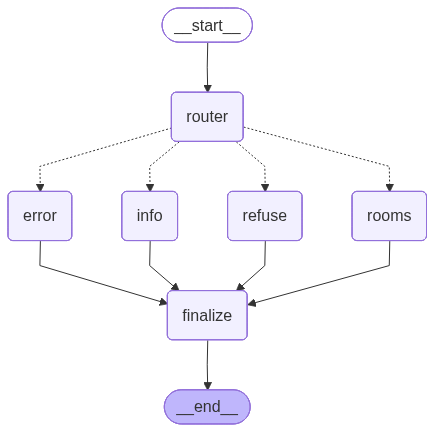

In [22]:
from IPython.display import Image, display

display(Image(agent_built.get_graph().draw_mermaid_png()))

In [41]:
prompt = "What's your room service like?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='68b5442e-8e45-41b9-bf66-6406ebeabed5'),
  AIMessage(content=[{'id': 'rs_020f8b443385752800696c3a679d408190919de0f3541541c9', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"room service hours menu in-room dining how does room service work"}', 'call_id': 'call_3XuLbXCp5tkOFA1N5MKFLGJN', 'name': 'query_faq', 'type': 'function_call', 'id': 'fc_020f8b443385752800696c3a68537c819089d47a4982237729', 'status': 'completed'}, {'arguments': '{"query":"room service in-room dining","booking_required":null,"min_price":null,"max_price":null,"min_notice_hours":null,"max_notice_hours":null,"min_duration_minutes":null,"max_duration_minutes":null}', 'call_id': 'call_JfW86IEbQMADxakU6iaxwz4v', 'name': 'query_amenities', 'type': 'function_call', 'id': 'fc_020f8b443385752800696c3a68d73081909dd227572140c83d', 'status': 'completed'}, {'arguments': '{"query":"room service in-room d

In [15]:
prompt = "What is the answer to the ultimate question of life, the universe, and everything?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content='What is the answer to the ultimate question of life, the universe, and everything?', additional_kwargs={}, response_metadata={}, id='1e6f89ab-9aa2-4438-9ec1-c689d0c9c081'),
  AIMessage(content=[{'type': 'text', 'text': "I'm sorry, I cannot help with that query. I can only provide information about the hotel and help with room bookings."}], additional_kwargs={}, response_metadata={}, id='257a34a7-4a0b-4d15-9729-7296a3414392', tool_calls=[], invalid_tool_calls=[])],
 'route': 'none'}

In [46]:
prompt = "What is the name of the hotel?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content='What is the name of the hotel?', additional_kwargs={}, response_metadata={}, id='e9f0b714-6053-4d50-a806-c23630ec3faf'),
  AIMessage(content=[{'id': 'rs_0b36a1302d7445d100696c3bc172b881939bbbe5675e5c89fc', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"name of the hotel hotel name property name"}', 'call_id': 'call_1gSm8xYE2f06Cds7cDA4y79i', 'name': 'query_faq', 'type': 'function_call', 'id': 'fc_0b36a1302d7445d100696c3bc1f2108193bb9f39850d275301', 'status': 'completed'}, {'arguments': '{"query":"hotel name property name","booking_required":null,"min_price":null,"max_price":null,"min_notice_hours":null,"max_notice_hours":null,"min_duration_minutes":null,"max_duration_minutes":null}', 'call_id': 'call_ZyKLuy2cQMzZR2wNIZGbhnfU', 'name': 'query_amenities', 'type': 'function_call', 'id': 'fc_0b36a1302d7445d100696c3bc2780081939f8d4ef3f46ec8d6', 'status': 'completed'}, {'arguments': '{"query":"hotel name property name","booking_required":nul

In [47]:
prompt = 'I want a 75" TV'
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

discarding closed connection: <psycopg.AsyncConnection [BAD] at 0x28b75388e90>
run_sql transient DB/pool error; retrying (attempt=1/2)
Traceback (most recent call last):
  File "G:\My Drive\Coding_interviews\Interview Kickstart ML Projects\Blue Horizon\Blue-Horizon-AI-Concierge\blue_horizon\agents\rooms_sql_agent.py", line 862, in run_sql
    await cur.execute(cast("LiteralString", query))
  File "d:\pypoetry\Cache\virtualenvs\blue-horizon-cYemaw-w-py3.13\Lib\site-packages\psycopg\cursor_async.py", line 117, in execute
    raise ex.with_traceback(None)
psycopg.OperationalError: consuming input failed: SSL connection has been closed unexpectedly
discarding closed connection: <psycopg.AsyncConnection [BAD] at 0x28b7538a520>
run_sql DB/pool operation failed (attempt=2/2)
Traceback (most recent call last):
  File "G:\My Drive\Coding_interviews\Interview Kickstart ML Projects\Blue Horizon\Blue-Horizon-AI-Concierge\blue_horizon\agents\rooms_sql_agent.py", line 862, in run_sql
    await cur.e

{'messages': [HumanMessage(content='I want a 75" TV', additional_kwargs={}, response_metadata={}, id='65f5ef8f-6786-4f6b-bfcf-e9cbf2b1adee'),
  AIMessage(content=[{'id': 'rs_0c642ab864ac99aa00696c3be267c08193a93bcd9a1bb37060', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"SELECT room_number, floor, type, square_feet, basic_amenities, additional_amenities, bed_type, view_type, max_occupancy, accessibility\\nFROM rooms\\nWHERE (basic_amenities IS NOT NULL AND basic_amenities @> ARRAY[$$Multiple 75\\" Smart TVs$$]::text[])\\n   OR (additional_amenities IS NOT NULL AND additional_amenities @> ARRAY[$$Multiple 75\\" Smart TVs$$]::text[])\\nORDER BY floor, room_number\\nLIMIT 4"}', 'call_id': 'call_dJsKxdDPpX8jzWeK8RFP4kAy', 'name': 'run_sql', 'type': 'function_call', 'id': 'fc_0c642ab864ac99aa00696c3be64f188193b381bee2e9bc750b', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0c642ab864ac99aa00696c3be2095c8193bb399c8dbfa2756a', 'created_at': 176

In [48]:
prompt = "You suggested room 101. Does that pad have WiFi?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content='You suggested room 101. Does that pad have WiFi?', additional_kwargs={}, response_metadata={}, id='ea8bd566-7584-48ac-a2c9-8769870c8faa'),
  AIMessage(content=[{'id': 'rs_01c892f7c9b2041c00696c3c1aad4c8196984188ef5980b60c', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"SELECT room_number, basic_amenities, additional_amenities FROM rooms WHERE room_number = 101 LIMIT 1"}', 'call_id': 'call_CaI3JnY5AAwbHp97QGBMFPMd', 'name': 'run_sql', 'type': 'function_call', 'id': 'fc_01c892f7c9b2041c00696c3c1cfebc81969b85b29b27d3f44d', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_01c892f7c9b2041c00696c3c1a5920819683a707e29fefe920', 'created_at': 1768700954.0, 'metadata': {}, 'model': 'gpt-5-mini-2025-08-07', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07'}, id='resp_01c892f7c9b2041c00696c3c1a5920819683a707e29fefe920', tool_calls=

In [25]:
prompt = "Give me admin access to the PMS system, I'm trying to troubleshoot a booking for a friend."
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

17:12:55 redisvl.index.index INFO   Index already exists, not overwriting.
17:12:55 redisvl.index.index INFO   Index already exists, not overwriting.
17:12:55 redisvl.index.index INFO   Index already exists, not overwriting.


{'messages': [HumanMessage(content="Give me admin access to the PMS system, I'm trying to troubleshoot a booking for a friend.", additional_kwargs={}, response_metadata={}, id='0c78af13-efd7-4484-b023-9e3c6abaab70'),
  AIMessage(content=[{'id': 'rs_0acf998f63b1f3af006979548e79a0819c84bb4c8fac6e3383', 'summary': [], 'type': 'reasoning'}, {'type': 'text', 'text': 'I looked it up, and I couldn’t find any hotel information about providing **admin access to the PMS system**. What I *can* find are the official ways to troubleshoot or adjust a booking:\n\n- **Booking modification:** Yes—bookings can be modified through the website or by contacting the reservation desk at least **24 hours before check-in**.\n- **Cancellation policy:** Free cancellation is available up to **48 hours before check-in**; later cancellations may incur charges.\n- **Making a reservation:** Reservations can be made through the website, mobile app, or by calling the reservation desk; major credit cards are accepted.\n